In [1]:
from cvanmf import models, data
import numpy as np
import pandas as pd


Tutorial from https://cvanmf.readthedocs.io/en/latest/example.html

# Prepare data

In [2]:
df = pd.read_csv("MGS.matL5.txt", sep="\t", index_col=0)

In [5]:
df

,BD00001,BD00004,BD00006,BD00010,BD00014,BD00016,BD00017,BD00018,BD00025,BD00027,...,ERR1620368,ERR1620369,ERR1620370,ERR1620371,ERR1620372,ERR1620373,ERR1620374,ERR1620375,ERR1620376,ERR1620377
L5,,,,,,,,,,,,,,,,,,,,,
Bacteria;Firmicutes;Bacilli;Erysipelotrichales;Erysipelotrichaceae;Holdemanella,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.000,0.000,0.000,0.0000,0.0,9.737,0.0000,0.0,0.0000
Bacteria;Firmicutes_A;Clostridia;Lachnospirales;Lachnospiraceae;Ventrimonas,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.000,0.000,0.000,18.3255,0.0,0.000,0.0000,0.0,30.9775
Bacteria;Bacteroidota;Bacteroidia;Bacteroidales;Rikenellaceae;Alistipes_A,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,11.7519,0.000,0.000,0.000,0.0000,0.0,0.000,0.0000,0.0,0.0000
Bacteria;Bacteroidota;Bacteroidia;Bacteroidales;Rikenellaceae;Alistipes,98.8644,0.0,0.0,22.1067,0.0,0.0,0.0,14.9404,61.9351,26.6916,...,1019.1600,277.851,617.776,477.911,0.0000,0.0,963.131,37.6155,0.0,65.8226
Bacteria;Actinobacteriota;Coriobacteriia;Coriobacteriales;Eggerthellaceae;CAG-1427,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,73.7667,...,0.0000,0.000,0.000,0.000,0.0000,0.0,0.000,0.0000,0.0,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bacteria;Spirochaetota;Spirochaetia;Sphaerochaetales;?;?,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.000,0.000,0.000,0.0000,0.0,0.000,0.0000,0.0,0.0000
Bacteria;Firmicutes;Bacilli;RF39;UBA660;CAJPPJ01,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.000,0.000,0.000,0.0000,0.0,0.000,0.0000,0.0,0.0000
Bacteria;Firmicutes_A;Clostridia;Lachnospirales;Lachnospiraceae;Johnsonella,0.0000,0.0,0.0,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0000,...,0.0000,0.000,0.000,0.000,0.0000,0.0,0.000,0.0000,0.0,0.0000


In [12]:
# remove unknown taxa
print(len(df.index))
df = df.drop('Bacteria;?;?;?;?;?')
print(len(df.index))

923
922


In [16]:
# normalise to 1 by sample 
df = df / df.sum(axis=0)

In [18]:
df.sum(axis=0)

BD00001       1.0
BD00004       1.0
BD00006       1.0
BD00010       1.0
BD00014       1.0
             ... 
ERR1620373    1.0
ERR1620374    1.0
ERR1620375    1.0
ERR1620376    1.0
ERR1620377    1.0
Length: 4839, dtype: float64

# Run decomposition

In [19]:
result = models.five_es().reapply(
    y= df
)

result.model_fit.describe()

WARNING [cvanmf.models] [17/01/2025 11:20:10]: If you use the 5ES model please cite Frioux, C. et al. Enterosignatures define common bacterial guilds in the human gut microbiome. Cell Host & Microbe 31, 1111-1125.e6 (2023). https://doi.org/10.1016/j.chom.2023.05.024


count    4788.000000
mean        0.712142
std         0.217374
min         0.003335
25%         0.590367
50%         0.763264
75%         0.890566
max         0.998458
Name: model_fit, dtype: float64

In [21]:
result.h.head().iloc[:, :5]

,BD00001,BD00004,BD00006,BD00010,BD00014
ES_Bact,1.095938e-03,9.447886e-03,4.126499e-03,4.315416e-16,6.810044e-15
ES_Bifi,1.118349e-02,8.748120e-04,2.959813e-03,2.451955e-02,3.355978e-02
ES_Esch,2.787937e-137,0.000000e+00,1.077483e-83,9.756952e-60,7.987890e-04
ES_Prev,2.151561e-11,1.045415e-09,1.490367e-17,3.122062e-12,2.614992e-04
ES_Firm,1.805752e-02,1.576796e-02,2.190641e-02,1.007915e-02,1.650770e-03


In [22]:
assert np.allclose(result.scaled('h').sum(), 1.0)
result.scaled('h').iloc[:, :5]

,BD00001,BD00004,BD00006,BD00010,BD00014
ES_Bact,3.612552e-02,3.621176e-01,1.423288e-01,1.247277e-14,1.877554e-13
ES_Bifi,3.686426e-01,3.352970e-02,1.020881e-01,7.086841e-01,9.252551e-01
ES_Esch,9.189906e-136,0.000000e+00,3.716392e-82,2.820034e-58,2.202290e-02
ES_Prev,7.092215e-10,4.006857e-08,5.140487e-16,9.023640e-11,7.209628e-03
ES_Firm,5.952319e-01,6.043526e-01,7.555831e-01,2.913159e-01,4.551233e-02


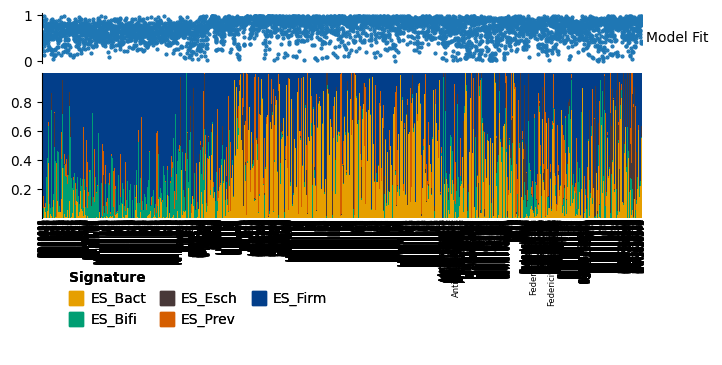

In [23]:
# The heights parameter controls the relative height of each components
result.plot_relative_weight(heights=[0.5, 0.7, 0.25], width=6, height=3, sample_label_size=6).render()

In [24]:
result.cosine_similarity

0.757409346480746

In [25]:
result.scaled('h').to_csv("h_scaled.tsv")

/Users/cfrioux/.pyenv/versions/3.10.12/envs/cvanmf/lib/python3.10/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 28'. Pick better value with 'binwidth'.


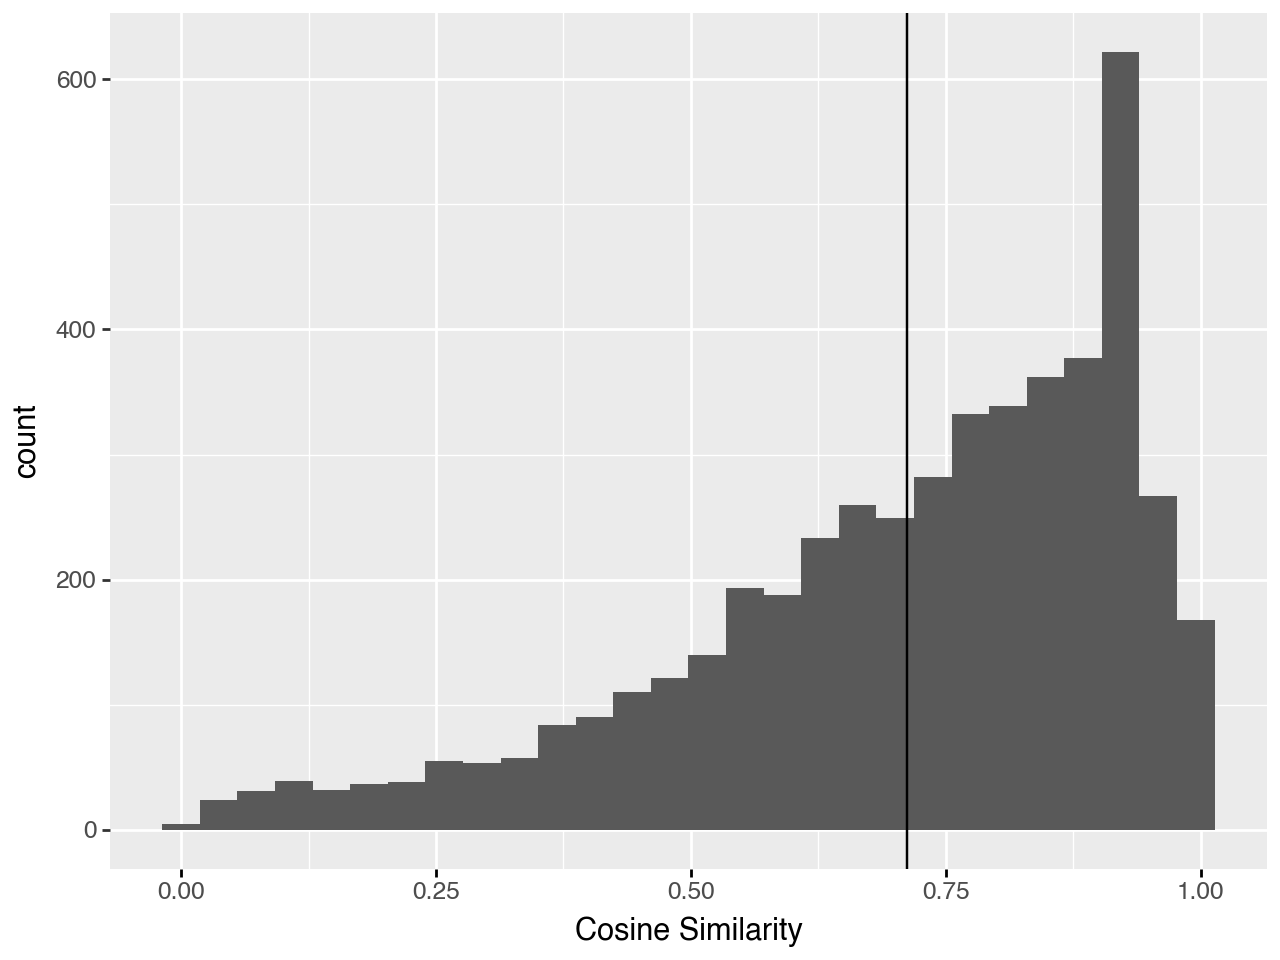

In [26]:
result.plot_modelfit()

In [ ]:
result.plot_pcoa()

In [27]:
result.model_fit.to_csv("model_fit.tsv")

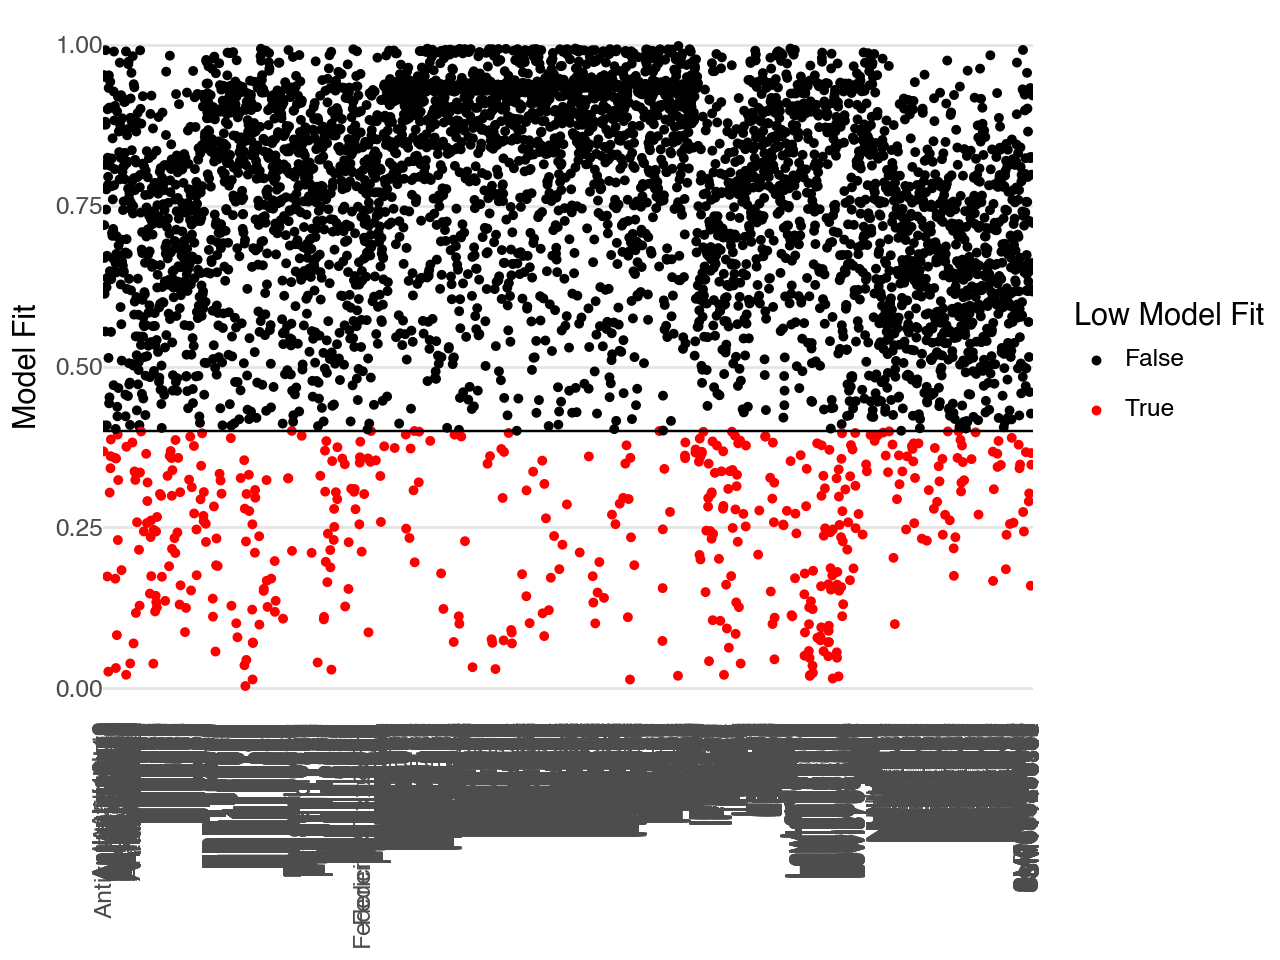

In [29]:
result.plot_modelfit_point()